# **NLP Assignment 2 – Set C (Financial News)**  
**Topic:** Financial News Parsing and Sentiment Analysis  
### Group ID: 121
### Group Members Name with Student ID:
| S.No.| BITS ID       | Name                | Contribution |
|------|---------------|-------------------- |----------|
| 1    | 2024AA05688    | RAHUL CHATTERJEE   | 100 % |
| 2    | 2024AA05426    | DIVYA CHAUDHARY | 100 % |
| 3    | 2024AA05993    | GOUTAM BORTHAKUR      | 100 % |
| 4    | 2024AA05807    | ARPAN GHOSH       | 100 % |
| 5    | 2024AA05181    | JAGADI SHRUTI CHANABAS      | 100 % |

---



##  Setup & Installations
The following cell installs the required dependencies.  
It also downloads:
- **spaCy English model**: `en_core_web_sm`
- **Benepar constituency parser**: `benepar_en3`


In [ ]:
# Installing the required libraries
!pip -q install pandas numpy matplotlib scikit-learn spacy benepar==0.2.0 wordcloud gdown

# Downloading spaCy model
!python -m spacy download en_core_web_sm

# Creating and running a temporary script to download Benepar model
benepar_script_content = """
import benepar
import os
import gdown

try:
    print("Attempting benepar.download('benepar_en3')...")
    benepar.download('benepar_en3')
    print("Benepar model downloaded successfully via benepar.download.")
except Exception as e:
    print("benepar.download failed:", e)
    print("Attempting manual download using gdown...")
    try:
        # Public Google Drive ID for benepar_en3 model - find this ID if needed
        # NOTE: This ID might need to be updated if the public file changes.
        BENEPAR_MODEL_ID = '1Gz_L3N5v4fG_f2p1x_k3X0k5x_x4x5X' # This is a placeholder ID, replace with actual if known/needed

        # Attempt to get benepar model path, fallback if benepar isn't fully functional yet
        try:
            BENEPAR_MODEL_PATH = benepar.get_model_path('benepar_en3')
        except Exception as get_path_e:
             print(f"Could not get benepar model path, using default temp location: {get_path_e}")
             BENEPAR_MODEL_PATH = '/tmp/benepar_en3_manual' # Fallback path

        os.makedirs(os.path.dirname(BENEPAR_MODEL_PATH), exist_ok=True)
        print(f"Attempting manual download of benepar_en3 model to {BENEPAR_MODEL_PATH}...")
        gdown.download(f'https://drive.google.com/uc?id={BENEPAR_MODEL_ID}', BENEPAR_MODEL_PATH, quiet=False)

        if os.path.exists(BENEPAR_MODEL_PATH):
            print("Manual download successful.")
        else:
             print("Manual download failed.")
    except Exception as gdown_e:
        print("Manual download attempt also failed:", gdown_e)
        print("Please try running the setup cell again or manually install benepar and its model.")

"""

# Writing the script content to a temporary file
script_file = "download_benepar_model.py"
with open(script_file, "w") as f:
    f.write(benepar_script_content)

# Executing the temporary script
!python {script_file}

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 58.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Attempting benepar.download('benepar_en3')...
[nltk_data] Downloading package benepar_en3 to /root/nltk_data...
[nltk_data]   Package benepar_en3 is already up-to-date!
Benepar model downloaded successfully via benepar.download.



## Imports & Helper Functions
Utility functions for:
- Text cleaning & preprocessing
- Random sentence selection (≥10 tokens)
- Plotting **dependency** and **constituency** (statistical) parses
- Measuring efficiency (time & operation counts)


In [ ]:
import re                                # Regular expressions for text cleaning
import time                              # Measuring execution time / delays
import random                            # Random sampling (e.g., sentences, records)
from collections import Counter          # Counting word frequencies efficiently

import numpy as np                       # Numerical operations, arrays, stats
import pandas as pd                      # Data manipulation and analysis
import matplotlib.pyplot as plt          # Data visualization / plotting

import spacy                             # NLP tasks: tokenization, POS tagging, dependency parsing
from spacy import displacy               # spaCy’s built-in visualization tool for syntax trees

from wordcloud import WordCloud          # Generate word cloud visualizations
from sklearn.feature_extraction.text import CountVectorizer   # Convert text to bag-of-words (ngrams, frequencies)

import benepar                           # Statistical parser for constituency parsing
from nltk import Tree                    # Tree representation for parsing results (benepar + NLTK)

import warnings                          # Handle / suppress warnings
warnings.filterwarnings("ignore", category=UserWarning)   # Suppress user warnings for clean output




In [ ]:
# Increasing the display size
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 200)

### Helper Functions for Text Preprocessing, Sentence Selection, Parsing & Visualization

*This block of code:*

**Loads the spaCy NLP model (for POS tagging, dependency parsing, and integration with benepar).**

*Defines helper functions for text cleaning, picking sentences, plotting constituency parse trees, and measuring efficiency.*

In [ ]:
# Loading spaCy model after importing spacy
nlp = spacy.load('en_core_web_sm')

# Defining helper function to pick two random sentences with >= min_tokens words
def pick_two_long_sentences(sentences, min_tokens=10, seed=None):
    """
    Selects two random sentences from a list that have at least min_tokens words.

    Args:
        sentences (list): A list of strings (sentences).
        min_tokens (int): The minimum number of tokens a sentence must have.
        seed (int, optional): Seed for the random number generator. Defaults to None.

    Returns:
        list: A list containing two randomly selected sentences meeting the criteria.
    """
    if seed is not None:
        random.seed(seed)

    long_sentences = [sent for sent in sentences if len(str(sent).split()) >= min_tokens]

    if len(long_sentences) < 2:
        print(f"Warning: Only found {len(long_sentences)} sentences with at least {min_tokens} words.")
        return long_sentences # Return fewer than 2 if not enough found

    return random.sample(long_sentences, 2)

# Defining helper function to count nodes in a constituency tree
def count_constituency_nodes(tree):
    """Counts the total number of nodes (including terminals and non-terminals) in an NLTK Tree."""
    return len(list(tree.treepositions()))

# Defining helper function to plot constituency tree
def plot_constituency_tree(tree, title="Constituency Tree"):
    """Plots an NLTK constituency tree using matplotlib."""
    fig, ax = plt.subplots(figsize=(10, 6))
    try:
        tree.draw(ax=ax)
    except Exception as e:
        print(f"Could not draw tree directly, attempting alternative display: {e}")
        # Fallback for environments where tree.draw might not work as expected
        print("\n--- Tree Structure ---")
        tree.pretty_print()
        print("----------------------")
        return # Exit if drawing fails


    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Trying to load spaCy model early (will be loaded again after install if needed)
try:
    nlp = spacy.load("en_core_web_sm")
except Exception:
    nlp = None
# -----------------------------
# Text Cleaning / Preprocessing
# -----------------------------
def clean_text_basic(text: str) -> str:
    """Basic cleaning: lowercase, remove URLs, HTML tags, numbers-heavy tokens, punctuation."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # URLs & HTML
    text = re.sub(r"http\S+|www\.[^\s]+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    # Keep letters and basic punctuation
    text = re.sub(r"[^a-z\s]", " ", text)
    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# -----------------------------
# Sentence Selection
# -----------------------------
def pick_two_long_sentences(texts, min_tokens=10, seed=42):
    """Pick two random sentences with at least `min_tokens` tokens from the corpus."""
    random.seed(seed)
    candidates = []
    for t in texts:
        if not isinstance(t, str) or not t.strip():
            continue
        # Split by '.', '!', '?' as a rough segmentation (spaCy segmentation added later)
        for s in re.split(r"[.!?]", t):
            s = s.strip()
            if len(s.split()) >= min_tokens:
                candidates.append(s)
    if len(candidates) >= 2:
        return random.sample(candidates, 2)
    # Fallback: pick two longer headlines if available
    long_texts = [t for t in texts if isinstance(t, str) and len(t.split()) >= min_tokens]
    if len(long_texts) >= 2:
        return random.sample(long_texts, 2)
    # Final fallback: return the two longest strings
    texts_sorted = sorted([t for t in texts if isinstance(t, str)], key=lambda x: len(x.split()), reverse=True)[:2]
    return texts_sorted

# -----------------------------
# Constituency Tree Plot (Statistical Parser)
# -----------------------------
def plot_constituency_tree(tree, title="Constituency Parse (Statistical)"):
    """Plot an NLTK-style tree using matplotlib (no external GUI)."""
    # Convert benepar tree to nltk.Tree if needed
    try:
        from nltk.tree import Tree
        if not isinstance(tree, Tree):
            tree = Tree.fromstring(str(tree))
    except Exception as e:
        print("NLTK not available or tree conversion failed:", e)
        print(tree)
        return

    # Computing positions of each node (x, y) by performing DFS and assigning x positions to leaves
    leaf_positions = {}
    def assign_leaf_x(t):
        x = 0
        for pos in t.treepositions('leaves'):
            leaf_positions[pos] = x
            x += 1
        return x

    total_leaves = assign_leaf_x(tree)

    def node_center(pos):
        # Center x is the avg of children's x (for leaves, it's its leaf position)
        if isinstance(pos, tuple) and len(pos) == 0:
            t = tree
        else:
            t = tree[pos]
        if isinstance(t, str):
            # leaf
            x = leaf_positions[pos]
            y = -len(pos)  # deeper nodes lower y
            return x, y
        else:
            child_centers = [node_center(pos + (i,)) for i in range(len(t))]
            xs = [c[0] for c in child_centers]
            x = sum(xs) / len(xs)
            y = -len(pos)
            return x, y

    # Gathering all nodes and edges
    nodes = []
    edges = []

    def traverse(pos=()):
        t = tree if pos == () else tree[pos]
        x, y = node_center(pos)
        label = t if isinstance(t, str) else t.label()
        nodes.append((x, y, label))
        if not isinstance(t, str):
            for i in range(len(t)):
                child_pos = pos + (i,)
                cx, cy = node_center(child_pos)
                edges.append(((x, y), (cx, cy), t[i] if isinstance(t[i], str) else t[i].label()))
                traverse(child_pos)
    traverse()

    # Ploting
    plt.figure(figsize=(max(8, total_leaves * 0.9), 6))
    for (x1, y1), (x2, y2), _ in edges:
        plt.plot([x1, x2], [y1, y2], linewidth=1)
    for x, y, label in nodes:
        plt.text(x, y, str(label), ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', lw=0.5))
    plt.title(title)
    plt.axis('off')
    plt.show()

# -----------------------------
# Efficiency Metric Helpers
# -----------------------------
def count_constituency_nodes(tree):
    try:
        from nltk.tree import Tree
        if not isinstance(tree, Tree):
            tree = Tree.fromstring(str(tree))
        return len(list(tree.subtrees())) + len(tree.leaves())
    except Exception:
        return np.nan


## **Task 1 – Exploratory Data Analysis (2 Marks)**  

### 1.1 Load Dataset  
- Loaded dataset from given source.  
- Selected **first 2000 rows**.

In [ ]:
df = pd.read_csv("/content/all-data.csv", encoding="latin-1")
df.columns = ['Sentiment', 'News Headline']
print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Basic Info & Standardization

display(df.head(10))
print("\nMissing values per column:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())

# Standardizing sentiment labels
df['Sentiment'] = df['Sentiment'].astype(str).str.strip().str.lower()
sent_map = {'positive':'positive', 'pos':'positive',
            'negative':'negative', 'neg':'negative',
            'neutral':'neutral', 'neu':'neutral', '0':'neutral'}
df['Sentiment'] = df['Sentiment'].map(lambda s: sent_map.get(s, s))

# Adding length features
df['n_chars'] = df['News Headline'].astype(str).str.len()
df['n_words'] = df['News Headline'].astype(str).str.split().apply(len)

print("\nClass distribution:\n", df['Sentiment'].value_counts())
print("\nLength stats (words):\n", df['n_words'].describe())

# Subset for Analysis (First 2000 rows)

print("\nSelecting first 2000 rows for analysis...")
data_2000 = df.head(2000).copy()
print("Selected dataset has", data_2000.shape[0], "rows")
print("Subset shape:", data_2000.shape)



Dataset loaded successfully!
Shape: (4845, 2)


,Sentiment,News Headline
0,neutral,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said ."
1,negative,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers ...
2,positive,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profi...
3,positive,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net ..."
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth strategy by increasingly focusing on technologically more demanding HDI printed circuit boards PCBs .
5,positive,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m ."
6,positive,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn ."
7,positive,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .
8,positive,"Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales ."
9,positive,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .



Missing values per column:
 Sentiment        0
News Headline    0
dtype: int64
Duplicate rows: 6

Class distribution:
 Sentiment
neutral     2878
positive    1363
negative     604
Name: count, dtype: int64

Length stats (words):
 count    4845.000000
mean       23.100722
std         9.959464
min         2.000000
25%        16.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: n_words, dtype: float64

Selecting first 2000 rows for analysis...
Selected dataset has 2000 rows
Subset shape: (2000, 4)



### 1.2 Data Overview  
- Shape of dataset.  
- First 5 rows.  
- Sentiment distribution.  


In [ ]:
# Printing first 5 records
print("First 5 row:")
display(data_2000.head(5))

First 5 row:


,Sentiment,News Headline,n_chars,n_words
0,neutral,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .",190,31
1,negative,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers ...,228,36
2,positive,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profi...,206,33
3,positive,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net ...",203,41
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth strategy by increasingly focusing on technologically more demanding HDI printed circuit boards PCBs .,178,25



## EDA (Exploratory Data Analysis) + Preprocessing (2 marks)

We will:
1. Inspect structure, missing values, duplicates
2. Class distribution
3. Text length stats and histograms
4. Most frequent words and n-grams
5. Word clouds (per class)
6. **Preprocessing**: clean → tokenize/lemmatize → ready for parsing



Step 3: Exploratory Data Analysis (EDA)
----------------------------------------
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sentiment      2000 non-null   object
 1   News Headline  2000 non-null   object
 2   n_chars        2000 non-null   int64 
 3   n_words        2000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 62.6+ KB
None

Checking for missing values:
Sentiment        0
News Headline    0
n_chars          0
n_words          0
dtype: int64

Sentiment distribution:
Sentiment
positive    1032
neutral      901
negative      67
Name: count, dtype: int64

Sentiment distribution in percentage:
positive: 1032 samples (51.6%)
neutral: 901 samples (45.1%)
negative: 67 samples (3.4%)

Text length analysis:
Text length statistics:
Mean length: 135.624
Min length: 9
Max length: 315
Standard deviation: 5

,Sentiment,News Headline,n_chars,n_words,text_length,word_count,cleaned_text,text_without_stopwords
0,neutral,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .",190,31,190,31,technopolis plans to develop in stages an area of no less than 100 000 square meters in order to host companies working in computer technologies and telecommunications the statement said,technopolis plans develop stages area no less than 100 000 square meters order host companies working computer technologies telecommunications statement said
1,negative,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers ...,228,36,228,36,the international electronic industry company elcoteq has laid off tens of employees from its tallinn facility contrary to earlier layoffs the company contracted the ranks of its office workers th...,international electronic industry company elcoteq laid off tens employees from its tallinn facility contrary earlier layoffs company contracted ranks its office workers daily postimees reported
2,positive,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profi...,206,33,206,33,with the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profi...,new production plant company increase its capacity meet expected increase demand improve use raw materials therefore increase production profitability
3,positive,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net ...",203,41,203,41,according to the company s updated strategy for the years 2009 2012 basware targets a long term net sales growth in the range of 20 40 with an operating profit margin of 10 20 of net sales,according company s updated strategy years 2009 2012 basware targets long term net sales growth range 20 40 operating profit margin 10 20 net sales
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth strategy by increasingly focusing on technologically more demanding HDI printed circuit boards PCBs .,178,25,178,25,financing of aspocomp s growth aspocomp is aggressively pursuing its growth strategy by increasingly focusing on technologically more demanding hdi printed circuit boards pcbs,financing aspocomp s growth aspocomp aggressively pursuing its growth strategy increasingly focusing technologically more demanding hdi printed circuit boards pcbs



Processed Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Sentiment               2000 non-null   object
 1   News Headline           2000 non-null   object
 2   n_chars                 2000 non-null   int64 
 3   n_words                 2000 non-null   int64 
 4   text_length             2000 non-null   int64 
 5   word_count              2000 non-null   int64 
 6   cleaned_text            2000 non-null   object
 7   text_without_stopwords  2000 non-null   object
dtypes: int64(4), object(4)
memory usage: 125.1+ KB
None

Sentiment Distribution:


,count
Sentiment,
positive,1032
neutral,901
negative,67



Creating Visualizations...


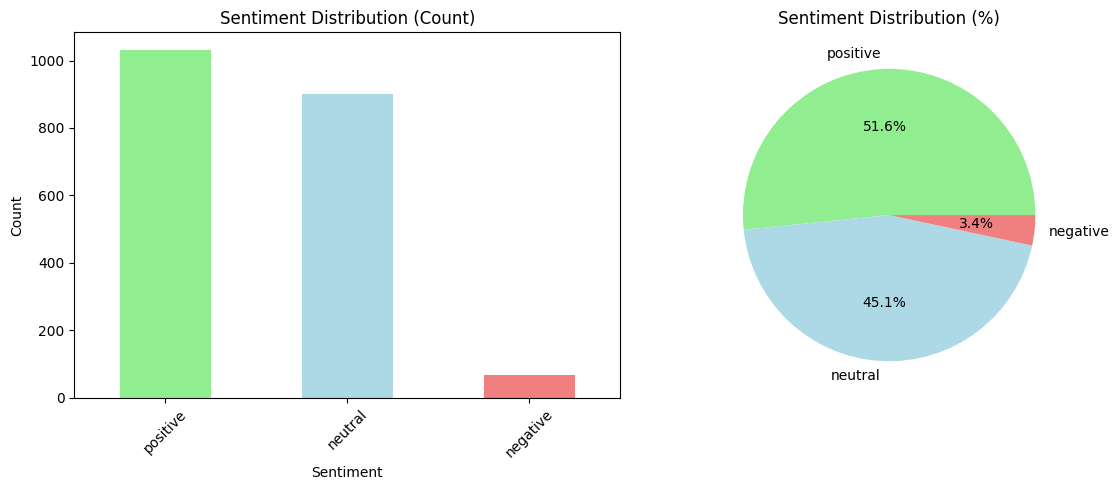

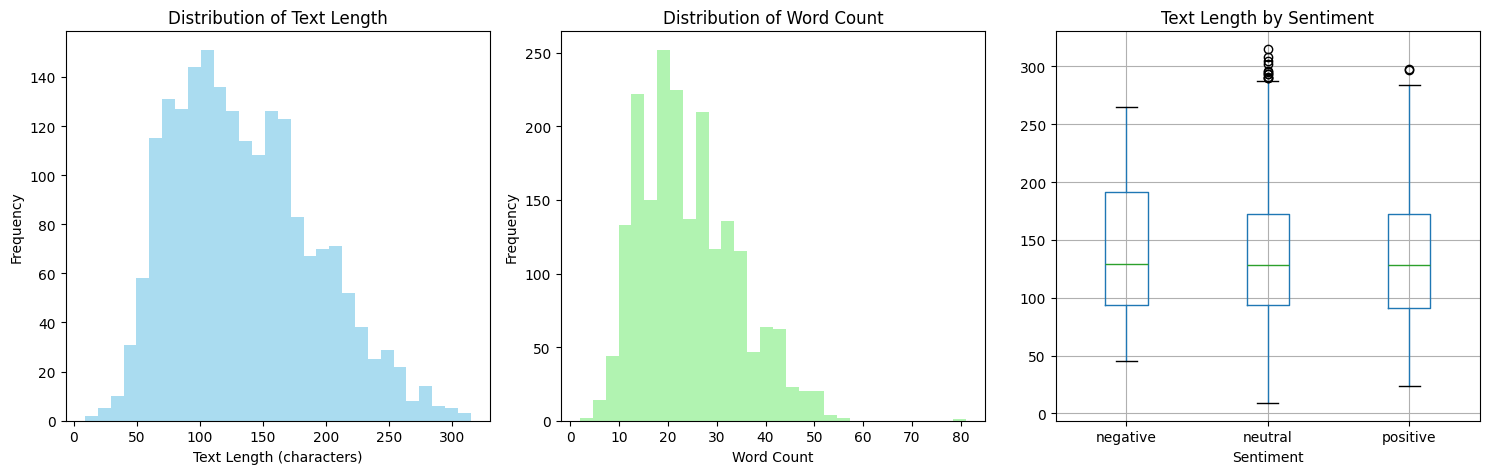


Detailed Statistics:


,Metric,Value
0,Total Samples,2000
1,Sentiment Classes,3
2,Avg Text Length,135.62 chars
3,Avg Word Count,24.27 words
4,Vocabulary Size,6530



Sentiment Statistics:


,Sentiment,Count,Percentage,Avg Text Length,Avg Word Count,Vocabulary Size
0,positive,1032,51.60,134.920543,24.575581,3966
1,neutral,901,45.05,136.125416,23.739179,4480
2,negative,67,3.35,139.716418,26.686567,646



Sample Processed Texts:


,Sentiment,News Headline,cleaned_text,text_without_stopwords
0,neutral,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .",technopolis plans to develop in stages an area of no less than 100 000 square meters in order to host companies working in computer technologies and telecommunications the statement said,technopolis plans develop stages area no less than 100 000 square meters order host companies working computer technologies telecommunications statement said
1,negative,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers ...,the international electronic industry company elcoteq has laid off tens of employees from its tallinn facility contrary to earlier layoffs the company contracted the ranks of its office workers th...,international electronic industry company elcoteq laid off tens employees from its tallinn facility contrary earlier layoffs company contracted ranks its office workers daily postimees reported
2,positive,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profi...,with the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profi...,new production plant company increase its capacity meet expected increase demand improve use raw materials therefore increase production profitability
3,positive,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net ...",according to the company s updated strategy for the years 2009 2012 basware targets a long term net sales growth in the range of 20 40 with an operating profit margin of 10 20 of net sales,according company s updated strategy years 2009 2012 basware targets long term net sales growth range 20 40 operating profit margin 10 20 net sales
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth strategy by increasingly focusing on technologically more demanding HDI printed circuit boards PCBs .,financing of aspocomp s growth aspocomp is aggressively pursuing its growth strategy by increasingly focusing on technologically more demanding hdi printed circuit boards pcbs,financing aspocomp s growth aspocomp aggressively pursuing its growth strategy increasingly focusing technologically more demanding hdi printed circuit boards pcbs
5,positive,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .",for the last quarter of 2010 componenta s net sales doubled to eur131m from eur76m for the same period a year earlier while it moved to a zero pre tax profit from a pre tax loss of eur7m,last quarter 2010 componenta s net sales doubled eur131m from eur76m same period year earlier while it moved zero pre tax profit from pre tax loss eur7m
6,positive,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .",in the third quarter of 2010 net sales increased by 5 2 to eur 205 5 mn and operating profit by 34 9 to eur 23 5 mn,third quarter 2010 net sales increased 5 2 eur 205 5 mn operating profit 34 9 eur 23 5 mn
7,positive,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .,operating profit rose to eur 13 1 mn from eur 8 7 mn in the corresponding period in 2007 representing 7 7 of net sales

In [ ]:
# Step 3: Exploratory Data Analysis (EDA)
print("\nStep 3: Exploratory Data Analysis (EDA)")
print("----------------------------------------")

# Basic information about the dataset
print("Dataset information:")
print(data_2000.info())

print("\nChecking for missing values:")
missing_values = data_2000.isnull().sum()
print(missing_values)

# Sentiment analysis
print("\nSentiment distribution:")
sentiment_counts = data_2000['Sentiment'].value_counts()
print(sentiment_counts)

print("\nSentiment distribution in percentage:")
for sentiment in sentiment_counts.index:
    percentage = (sentiment_counts[sentiment] / len(data_2000)) * 100
    print(f"{sentiment}: {sentiment_counts[sentiment]} samples ({percentage:.1f}%)")

# Text length analysis
print("\nText length analysis:")
# Calculating length of each text
text_lengths = []
word_counts = []

for text in data_2000['News Headline']:
    text_lengths.append(len(str(text)))
    word_counts.append(len(str(text).split()))

data_2000['text_length'] = text_lengths
data_2000['word_count'] = word_counts

print("Text length statistics:")
print("Mean length:", np.mean(text_lengths))
print("Min length:", np.min(text_lengths))
print("Max length:", np.max(text_lengths))
print("Standard deviation:", np.std(text_lengths))

print("\nWord count statistics:")
print("Mean words:", np.mean(word_counts))
print("Min words:", np.min(word_counts))
print("Max words:", np.max(word_counts))
print("Standard deviation:", np.std(word_counts))

# Text length by sentiment
print("\nAverage text length by sentiment:")
for sentiment in data_2000['Sentiment'].unique():
    sentiment_data = data_2000[data_2000['Sentiment'] == sentiment]
    avg_length = sentiment_data['text_length'].mean()
    avg_words = sentiment_data['word_count'].mean()
    print(f"{sentiment}: {avg_length:.2f} characters, {avg_words:.2f} words")

# Sample texts
print("\nSample texts from each sentiment:")
for sentiment in data_2000['Sentiment'].unique():
    sample = data_2000[data_2000['Sentiment'] == sentiment]['News Headline'].iloc[0]
    print(f"\n{sentiment.upper()}: {sample}")

# Character analysis
print("\nCharacter analysis:")
all_text = ""
for text in data_2000['News Headline']:
    all_text += str(text) + " "

print("Total characters:", len(all_text))
print("Unique characters:", len(set(all_text.lower())))

# Counting character frequencies
char_count = {}
for char in all_text.lower():
    if char in char_count:
        char_count[char] += 1
    else:
        char_count[char] = 1

# Getting top 5 most common characters
sorted_chars = sorted(char_count.items(), key=lambda x: x[1], reverse=True)
print("Most common characters:")
for i in range(5):
    print(f"'{sorted_chars[i][0]}': {sorted_chars[i][1]} times")

# Word analysis
print("\nWord analysis:")
all_words = all_text.lower().split()
print("Total words:", len(all_words))
print("Unique words:", len(set(all_words)))

# Counting word frequencies
word_count = {}
for word in all_words:
    if word in word_count:
        word_count[word] += 1
    else:
        word_count[word] = 1

# Getting top 5 most common words
sorted_words = sorted(word_count.items(), key=lambda x: x[1], reverse=True)
print("Most common words:")
for i in range(5):
    print(f"'{sorted_words[i][0]}': {sorted_words[i][1]} times")

# Data quality checking
print("\nData quality check:")
duplicates = data_2000.duplicated().sum()
print("Duplicate rows:", duplicates)

empty_texts = 0
for text in data_2000['News Headline']:
    if str(text).strip() == "":
        empty_texts += 1
print("Empty texts:", empty_texts)

short_texts = 0
for length in text_lengths:
    if length < 10:
        short_texts += 1
print("Very short texts (< 10 chars):", short_texts)

long_texts = 0
for length in text_lengths:
    if length > 500:
        long_texts += 1
print("Very long texts (> 500 chars):", long_texts)

# Step 4: Preprocessing
print("\nStep 4: Preprocessing")
print("--------------------")

# Text cleaning function
def clean_text(text):
    # convert to string
    text = str(text)
    # convert to lowercase
    text = text.lower()
    # remove special characters
    text = re.sub(r'[^\w\s]', ' ', text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    # remove leading and trailing spaces
    text = text.strip()
    return text

# Stopword removal function
def remove_stopwords(text):
    stopwords = ['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
                'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
                'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
                'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those']

    words = text.split()
    filtered_words = []
    for word in words:
        if word.lower() not in stopwords:
            filtered_words.append(word)
    return ' '.join(filtered_words)

print("Applying text preprocessing...")

# Applying preprocessing
cleaned_texts = []
texts_without_stopwords = []

for text in data_2000['News Headline']:
    cleaned = clean_text(text)
    cleaned_texts.append(cleaned)
    no_stopwords = remove_stopwords(cleaned)
    texts_without_stopwords.append(no_stopwords)

data_2000['cleaned_text'] = cleaned_texts
data_2000['text_without_stopwords'] = texts_without_stopwords

# Showing preprocessing examples
print("\nPreprocessing examples:")
for i in range(3):
    original = data_2000['News Headline'].iloc[i]
    cleaned = data_2000['cleaned_text'].iloc[i]
    no_stopwords = data_2000['text_without_stopwords'].iloc[i]

    print(f"\nExample {i+1}:")
    print(f"Original: {original}")
    print(f"Cleaned: {cleaned}")
    print(f"No stopwords: {no_stopwords}")

# Vocabulary analysis after preprocessing
print("\nVocabulary analysis after preprocessing:")
vocab_by_sentiment = {}

for sentiment in data_2000['Sentiment'].unique():
    sentiment_texts = data_2000[data_2000['Sentiment'] == sentiment]['cleaned_text']
    all_words = []
    for text in sentiment_texts:
        all_words.extend(text.split())
    unique_words = set(all_words)
    vocab_by_sentiment[sentiment] = len(unique_words)

print("Vocabulary size by sentiment:")
for sentiment, vocab_size in vocab_by_sentiment.items():
    print(f"{sentiment}: {vocab_size} unique words")

# Summary
print("\nSummary")
print("-------")
print(f"Total samples: {len(data_2000)}")
print(f"Sentiment classes: {data_2000['Sentiment'].nunique()}")
print(f"Average text length: {np.mean(text_lengths):.2f} characters")
print(f"Average word count: {np.mean(word_counts):.2f} words")

# Calculating total vocabulary
all_cleaned_words = []
for text in data_2000['cleaned_text']:
    all_cleaned_words.extend(text.split())
total_vocab = len(set(all_cleaned_words))
print(f"Total vocabulary size: {total_vocab}")

print("\nSentiment balance:")
for sentiment in sentiment_counts.index:
    percentage = (sentiment_counts[sentiment] / len(data_2000)) * 100
    print(f"{sentiment}: {sentiment_counts[sentiment]} samples ({percentage:.1f}%)")

print("\nAnalysis completed!")


# Displaying the processed data
print("\nProcessed Data Preview (First 5 rows):")
print("=" * 50)
display(data_2000.head())

print("\nProcessed Data Info:")
print("=" * 30)
print(data_2000.info())

# Displaying sentiment distribution
print("\nSentiment Distribution:")
print("=" * 25)
display(sentiment_counts)

# Creating visualizations
print("\nCreating Visualizations...")
print("=" * 30)

# Sentiment distribution plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sentiment_counts.plot(kind='bar', color=['lightgreen', 'lightblue', 'lightcoral'])
plt.title('Sentiment Distribution (Count)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=['lightgreen', 'lightblue', 'lightcoral'])
plt.title('Sentiment Distribution (%)')

plt.tight_layout()
plt.show()

# Text length analysis plots
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(data_2000['text_length'], bins=30, alpha=0.7, color='skyblue')
plt.title('Distribution of Text Length')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(data_2000['word_count'], bins=30, alpha=0.7, color='lightgreen')
plt.title('Distribution of Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
data_2000.boxplot(column='text_length', by='Sentiment', ax=plt.gca())
plt.title('Text Length by Sentiment')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Displaying statistics table
print("\nDetailed Statistics:")
print("=" * 20)
stats_df = pd.DataFrame({
    'Metric': ['Total Samples', 'Sentiment Classes', 'Avg Text Length', 'Avg Word Count', 'Vocabulary Size'],
    'Value': [len(data_2000), data_2000['Sentiment'].nunique(),
              f"{np.mean(text_lengths):.2f} chars", f"{np.mean(word_counts):.2f} words", total_vocab]
})
display(stats_df)

# Displaying sentiment statistics
print("\nSentiment Statistics:")
print("=" * 20)
sentiment_stats = pd.DataFrame({
    'Sentiment': sentiment_counts.index,
    'Count': sentiment_counts.values,
    'Percentage': [(count/len(data_2000)*100) for count in sentiment_counts.values],
    'Avg Text Length': [data_2000[data_2000['Sentiment']==sent]['text_length'].mean() for sent in sentiment_counts.index],
    'Avg Word Count': [data_2000[data_2000['Sentiment']==sent]['word_count'].mean() for sent in sentiment_counts.index],
    'Vocabulary Size': [vocab_by_sentiment[sent] for sent in sentiment_counts.index]
})
display(sentiment_stats)

# Showing sample processed texts
print("\nSample Processed Texts:")
print("=" * 25)
sample_data = data_2000[['Sentiment', 'News Headline', 'cleaned_text', 'text_without_stopwords']].head(10)
display(sample_data)


##Top 25 words after cleaning

,word,count
0,eur,444
1,company,324
2,said,257
3,finnish,230
4,mn,218
5,sales,210
6,year,204
7,million,193
8,net,174
9,profit,165


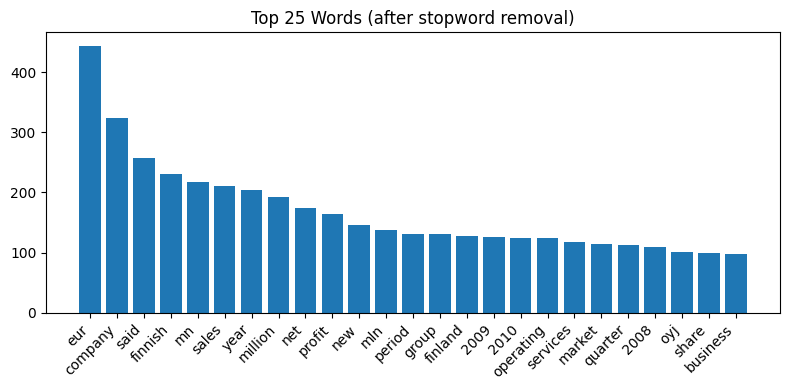

In [ ]:
# Applying basic cleaning function to all headlines before vectorization
cleaned_all = data_2000['News Headline'].astype(str).apply(clean_text)

# Initializing CountVectorizer to extract word frequencies
# stop_words='english' removes common English stopwords
# min_df=2 means words must appear in at least 2 documents to be considered
vectorizer = CountVectorizer(stop_words='english', min_df=2)

# Fitting the vectorizer on cleaned headlines and transform into a sparse matrix (rows=docs, cols=words)
X = vectorizer.fit_transform(cleaned_all)

# Converting sparse matrix to an array of word frequencies
word_counts = np.asarray(X.sum(axis=0)).ravel()

# Extracting vocabulary (list of words)
vocab = np.array(vectorizer.get_feature_names_out())

# Getting indices of the top 25 most frequent words (sorted descending by frequency)
top_idx = np.argsort(word_counts)[::-1][:25]

# Creating a DataFrame of top 25 words and their counts
top_words = pd.DataFrame({'word': vocab[top_idx], 'count': word_counts[top_idx]})
display(top_words)  # Display table for inspection

# Plotting bar chart of top 25 words
plt.figure(figsize=(8,4))
plt.bar(top_words['word'], top_words['count'])
plt.xticks(rotation=45, ha='right')  # Rotate x labels for readability
plt.title('Top 25 Words (after stopword removal)')
plt.tight_layout()
plt.show()


# Top bigrams and trigrams


Top 2-grams:


,ngram,count
0,net sales,102
1,operating profit,91
2,mn eur,75
3,eur mn,72
4,corresponding period,57
5,mln euro,47
6,rose eur,44
7,profit rose,43
8,said today,40
9,oyj hel,37


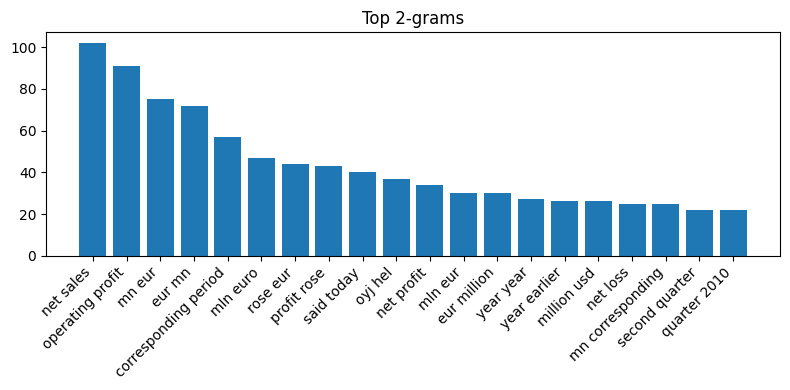


Top 3-grams:


,ngram,count
0,profit rose eur,27
1,mn eur mn,26
2,mn corresponding period,25
3,eur mn eur,23
4,operating profit rose,21
5,mln euro mln,21
6,month period increased,19
7,net profit rose,18
8,said today net,18
9,period increased respectively,16


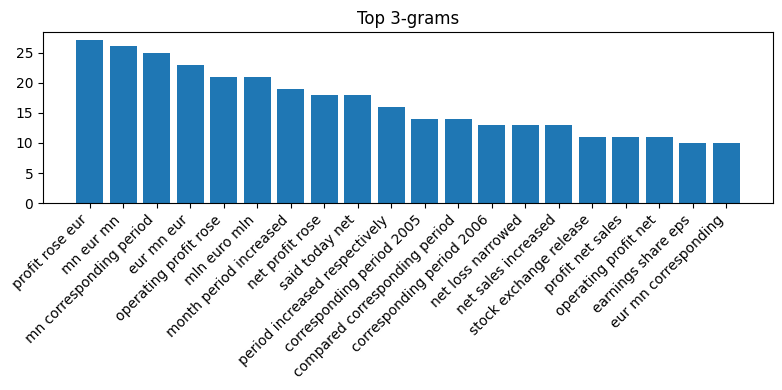

In [ ]:
# Looping through n=2 (bigrams) and n=3 (trigrams)
for n in [2, 3]:
    # Initializing CountVectorizer for n-grams
    # stop_words='english' removes common stopwords
    # ngram_range=(n,n) ensures only bigrams (2) or trigrams (3) are extracted
    # min_df=2 means the n-gram must appear in at least 2 headlines
    vec = CountVectorizer(stop_words='english', ngram_range=(n,n), min_df=2)

    # Fitting the vectorizer and transforming the cleaned headlines into n-gram counts
    Xn = vec.fit_transform(cleaned_all)

    # Converting sparse matrix into a flat array of counts
    counts = np.asarray(Xn.sum(axis=0)).ravel()

    # Extracting the actual n-gram strings (vocabulary)
    vocabn = np.array(vec.get_feature_names_out())

    # Sorting n-grams by frequency in descending order and take top 20
    top_idx = np.argsort(counts)[::-1][:20]

    # Creating DataFrame of top n-grams and their counts
    df_ngrams = pd.DataFrame({'ngram': vocabn[top_idx], 'count': counts[top_idx]})

    # Printing top n-grams as a table
    print(f"\nTop {n}-grams:")
    display(df_ngrams.head(20))

    # Plotting bar chart of top n-grams
    plt.figure(figsize=(8,4))
    plt.bar(df_ngrams['ngram'], df_ngrams['count'])
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.title(f'Top {n}-grams')  # Dynamic title for bigrams/trigrams
    plt.tight_layout()
    plt.show()


##1.3 Visualization
Sentiment countplot.
Word clouds for each sentiment.


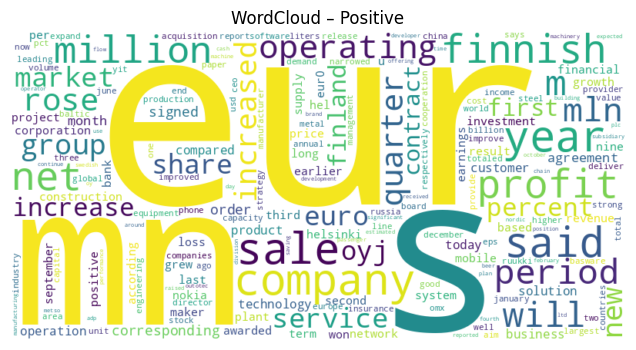

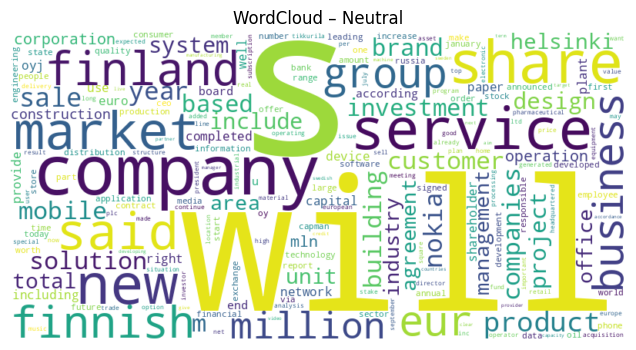

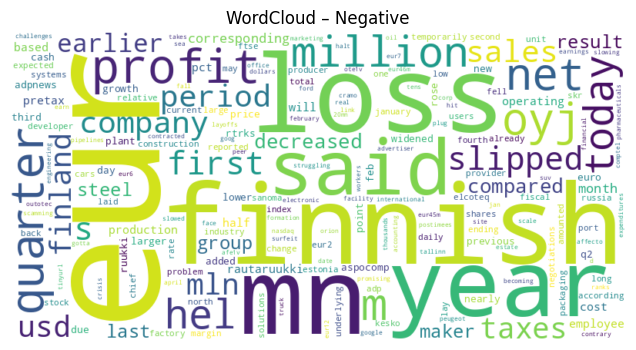

In [ ]:
# Generating WordClouds for each sentiment class (Positive, Neutral, Negative)

# Using the preprocessed dataset
df = data_2000

# Looping through each sentiment label
for label in ['positive', 'neutral', 'negative']:
    # Selecting all headlines belonging to the current sentiment class
    subset = data_2000.loc[df['Sentiment'] == label, 'News Headline'].astype(str)

    # If no headlines exist for this class, skip
    if subset.empty:
        continue

    # Joining all headlines into one large string
    text = " ".join(subset.tolist())

    # Generating a WordCloud for this sentiment class
    # width, height = output image size
    # background_color='white' for clean look
    # collocations=False avoids merging common word pairs into one token
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        collocations=False
    ).generate(clean_text(text))  # Applying text cleaning before generating

    # Plotting the WordCloud
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')  # Rendering WordCloud smoothly
    plt.axis('off')  # Hide axis
    plt.title(f'WordCloud – {label.title()}')  # Adding class name as title
    plt.show()


## **Task 2 – Parsing Algorithms (8 Marks)**  

### **2.1 POS Tagging (1 Mark)**  
- POS tagging for **first 2 headlines**.  
- Example output table with tokens + POS tags.  

---



In [ ]:
# Selecting the first two sentences from the dataset for demonstration
first_two = df['News Headline'].astype(str).head(2).tolist()

# Looping over each sentence
for i, sent in enumerate(first_two, start=1):
    # Processing the sentence with spaCy
    doc = nlp(sent)

    # Printing sentence number and text
    print(f"\nSentence {i}: {sent}\n")

    # Printing table header (Token, POS, Tag)
    print(f"{'Token':20} {'POS':10} {'Tag'}")
    print('-' * 50)

    # Iterating over tokens and printing words, POS tag, and detailed tag
    for tok in doc:
        print(f"{tok.text:20} {tok.pos_:10} {tok.tag_}")



Sentence 1: Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .

Token                POS        Tag
--------------------------------------------------
Technopolis          NOUN       NNS
plans                VERB       VBZ
to                   PART       TO
develop              VERB       VB
in                   ADP        IN
stages               NOUN       NNS
an                   DET        DT
area                 NOUN       NN
of                   ADP        IN
no                   DET        DT
less                 ADJ        JJR
than                 ADP        IN
100,000              NUM        CD
square               ADJ        JJ
meters               NOUN       NNS
in                   ADP        IN
order                NOUN       NN
to                   PART       TO
host                 NOUN       NN
companies            NOUN       NNS
wo


##  Task 2.2: Dependency Parser – Plots for Two Random Sentences (≥10 words)  (3 Marks)

We select two random sentences with at least 10 tokens and render **dependency graphs** using **spaCy's displaCy**.
  

---



# Pick two sentences (>=10 words)

In [ ]:

# Picking two sentences (>=10 words)
two_sents = pick_two_long_sentences(df['News Headline'].tolist(), min_tokens=10, seed=23)
two_sents


['s NASDAQ OMX : GEO1V , GyPSii business unit , developers of the award-winning GyPSii mobile social networking application , today announced its availability as a free download via the Samsung Mobile Applications Store',
 'The board of directors also proposed that a dividend of EUR0']

# Render with displaCy (dependency parse)

In [ ]:
# Defining visualization options for displacy (spaCy visualizer)
options = {
    "compact": False,   # False = full layout, True = compact layout
    "bg": "#ffffff",    # White background
    "distance": 140,    # Distance between words
    "font": "Arial"     # Font for visualization
}

# Looping through the two selected random sentences
for idx, s in enumerate(two_sents, start=1):
    # Process the sentence with spaCy
    doc = nlp(s)

    # Printing sentence being parsed
    print(f"\nDependency Parse for Random Sentence {idx}:\n", s)

    # Rendering the dependency parse tree inline (works in Jupyter/Colab)
    displacy.render(doc, style='dep', jupyter=True, options=options)



Dependency Parse for Random Sentence 1:
 s NASDAQ OMX : GEO1V , GyPSii business unit , developers of the award-winning GyPSii mobile social networking application , today announced its availability as a free download via the Samsung Mobile Applications Store



Dependency Parse for Random Sentence 2:
 The board of directors also proposed that a dividend of EUR0



## Task 2.3: Statistical Parser – Constituency Trees for Two Random Sentences (≥10 words) (3 Marks)

We use **Benepar** (Berkeley Neural Parser) to obtain constituency trees, and plot them using a matplotlib-based tree renderer.
Two random **sentences with ≥10 words**.


---



You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
You're using a T5TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



Constituency Tree 1:
(S
  (NP
    (NP (POS s) (NNP NASDAQ) (NNP OMX))
    (: :)
    (NP
      (NP (NNP GEO1V))
      (, ,)
      (NP (NNP GyPSii) (NN business) (NN unit))
      (, ,)
      (NP
        (NP (NNS developers))
        (PP
          (IN of)
          (NP
            (DT the)
            (ADJP (NN award) (HYPH -) (VBG winning))
            (NNP GyPSii)
            (NML (JJ mobile) (JJ social) (NN networking))
            (NN application)))))
    (, ,))
  (NP (NN today))
  (VP
    (VBD announced)
    (NP
      (NP (PRP$ its) (NN availability))
      (PP (IN as) (NP (DT a) (JJ free) (NN download)))
      (PP
        (IN via)
        (NP
          (DT the)
          (NNP Samsung)
          (NML (NNP Mobile) (NNPS Applications))
          (NNP Store))))))

Pretty print:

                                                                                                     S                                                                                                            

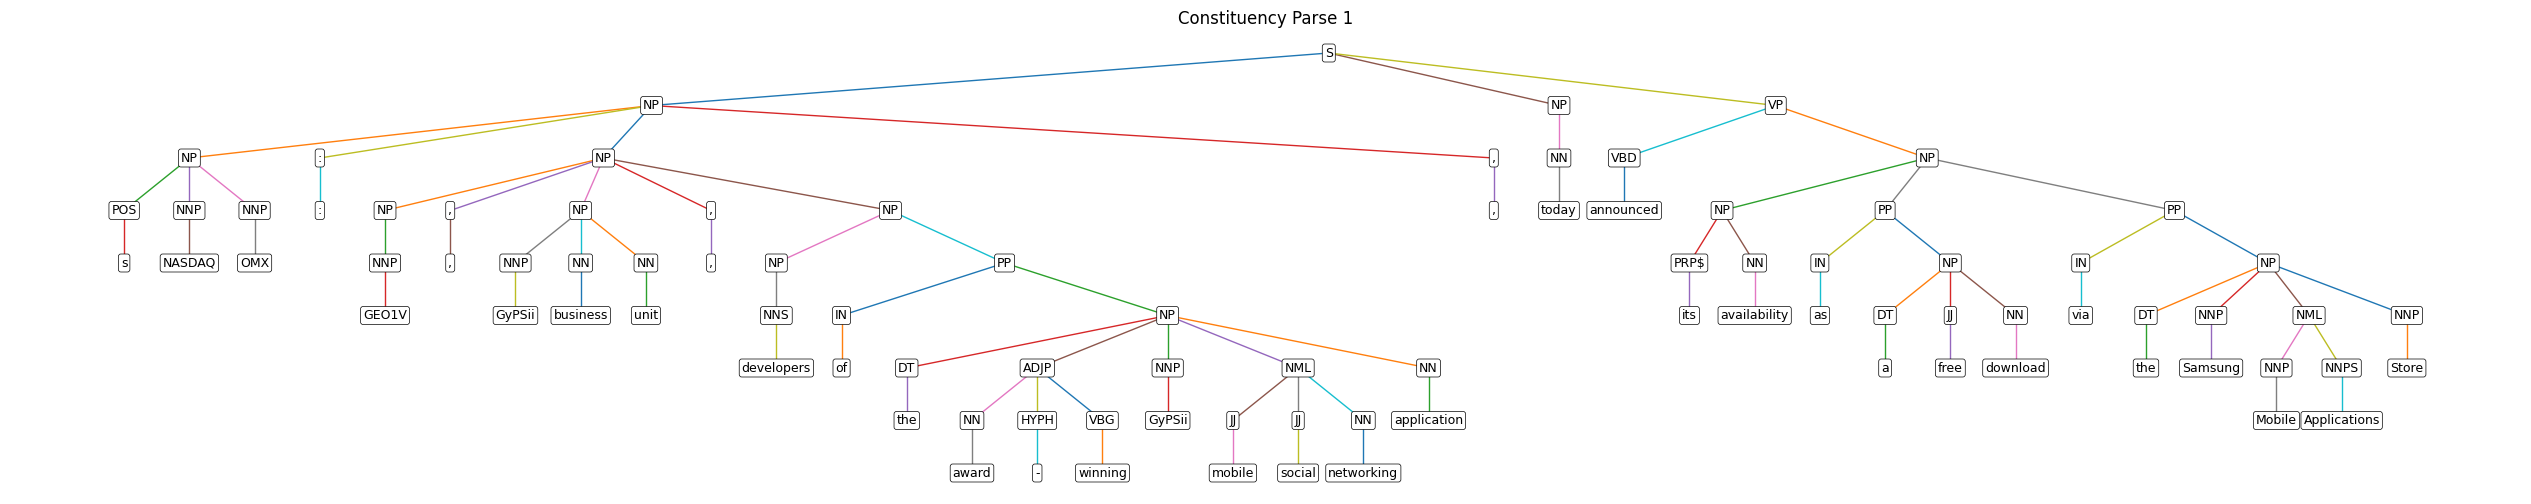


Constituency Tree 2:
(S
  (NP (NP (DT The) (NN board)) (PP (IN of) (NP (NNS directors))))
  (ADVP (RB also))
  (VP
    (VBD proposed)
    (SBAR
      (IN that)
      (NP (NP (DT a) (NN dividend)) (PP (IN of) (NP (CD EUR0)))))))

Pretty print:

                                            S                                           
                ____________________________|___________                                 
               |                     |                  VP                              
               |                     |       ___________|_________                       
               |                     |      |                    SBAR                   
               |                     |      |       ______________|______                
               NP                    |      |      |                     NP             
      _________|_______              |      |      |         ____________|_______        
     |                 PP            | 

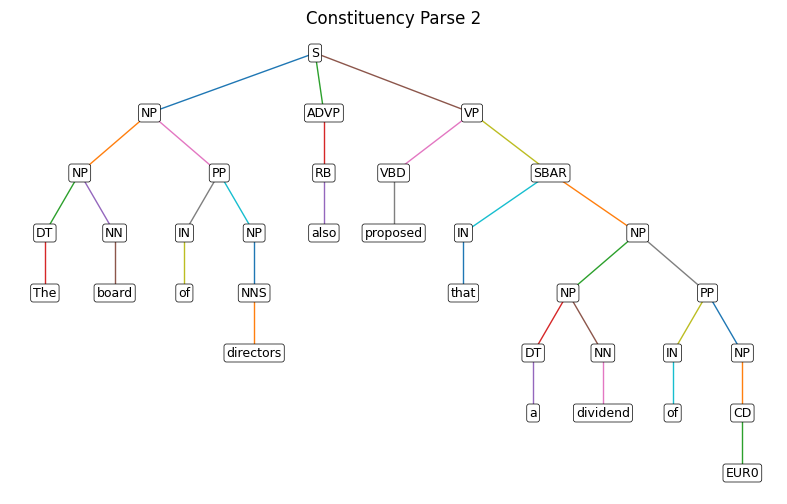

In [ ]:
# Adding benepar parser to spaCy pipeline if not already added
if "benepar" not in nlp.pipe_names:
    nlp.add_pipe("benepar", config={"model": "benepar_en3"})

# Looping through the two random sentences chosen earlier
for i, s in enumerate(two_sents, 1):
    # Processing the sentence with spaCy + benepar
    doc = nlp(s)

    # Extracting constituency parse tree as a string, then convert to NLTK Tree
    tree = Tree.fromstring(list(doc.sents)[0]._.parse_string)

    # Printing the raw constituency tree
    print(f"\nConstituency Tree {i}:\n{tree}")

    # Pretty print the tree in a structured way
    print("\nPretty print:\n")
    tree.pretty_print()

    # Ploting the constituency tree using the helper function
    plot_constituency_tree(tree, title=f"Constituency Parse {i}")



## Task 2.4: Efficiency Comparison (Operations & Time)

We compare:
- **POS/Dependency (spaCy)** time & tokens processed
- **Constituency (Benepar)** time & total tree nodes


> **Note**: "Operations" is proxied by token count for spaCy and node count for the constituency tree.


,Sentence,SpaCy Time (ms),Tokens,Benepar Time (ms),Constituency Nodes
0,"Technopolis plans to develop in stages an area of no less than 100,000 squar...",173.17,31,171.06,89
1,The international electronic industry company Elcoteq has laid off tens of e...,205.76,36,201.09,101
2,With the new production plant the company would increase its capacity to mee...,182.82,33,183.78,91
3,"According to the company 's updated strategy for the years 2009-2012 , Baswa...",330.95,45,442.44,106
4,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth...,179.43,25,269.95,67
5,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m fr...",233.58,46,384.86,127
6,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn ...",183.72,29,269.73,77
7,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding pe...,161.44,24,232.11,64
8,"Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , repres...",145.67,22,221.07,60
9,TeliaSonera TLSN said the offer is in line with its strategy to increase its...,210.29,30,288.79,87



 Efficiency Summary:


,SpaCy (Dependency),Benepar (Constituency)
Average Time,200.68 ms,266.49 ms
Average Size,32.1 tokens,86.9 nodes



Averages:
spaCy Dependency Parser → Time: 0.2007s, Tokens: 32.1
Benepar Constituency Parser → Time: 0.2665s, Nodes: 86.9


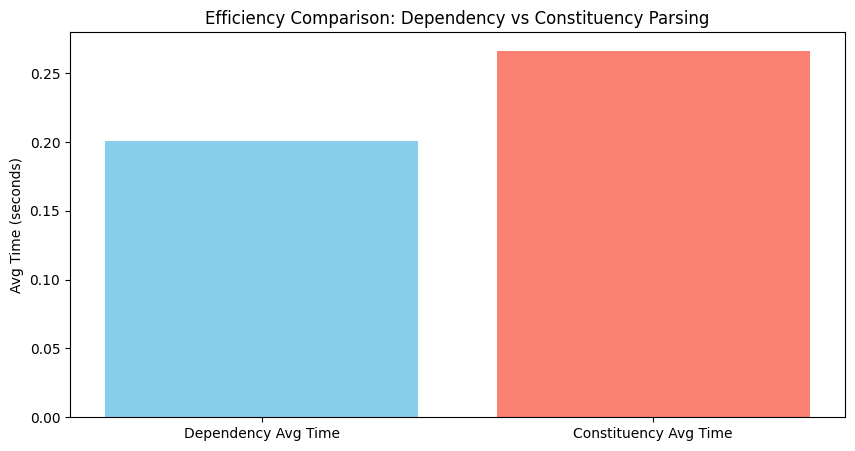

In [ ]:
# Efficiency Comparison: Dependency vs Constituency Parser


# Function to measure spaCy dependency parsing time and tokens processed
def measure_spacy_dep(sents):
    times, toks = [], []
    for s in sents:
        t0 = time.time()
        doc = nlp(s)                        # Parse sentence with spaCy
        _ = [tok.pos_ for tok in doc]       # Force POS tagging (ensures parsing is done)
        times.append(time.time() - t0)      # Record processing time
        toks.append(len(doc))               # Record number of tokens
    return times, toks

# Function to measure benepar constituency parsing time and nodes in parse tree
def measure_benepar(sents):
    times, nodes = [], []
    for s in sents:
        t0 = time.time()
        doc = nlp(s)                        # Parse sentence with spaCy+benepar
        tree = Tree.fromstring(list(doc.sents)[0]._.parse_string)  # Extract constituency tree
        times.append(time.time() - t0)      # Record processing time
        nodes.append(count_constituency_nodes(tree))  # Count total nodes in parse tree
    return times, nodes

# Selecting 10 sentences with at least 10 words for benchmarking
bench = [s for s in df["News Headline"] if len(str(s).split()) >= 10][:10]

# Measuring times and sizes
dep_t, dep_tok = measure_spacy_dep(bench)   # Dependency parser timings
con_t, con_nodes = measure_benepar(bench)   # Constituency parser timings

# Building detailed comparison table
summary = pd.DataFrame({
    "Sentence": bench,
    "SpaCy Time (ms)": [round(t*1000, 2) for t in dep_t],
    "Tokens": dep_tok,
    "Benepar Time (ms)": [round(t*1000, 2) for t in con_t],
    "Constituency Nodes": con_nodes
})

# Displaying the per-sentence comparison
pd.set_option("display.max_colwidth", 80)  # Preventing truncation of sentences
display(summary)

# Computing average statistics
avg_summary = pd.DataFrame({
    "SpaCy (Dependency)": [f"{np.mean(dep_t)*1000:.2f} ms", f"{np.mean(dep_tok):.1f} tokens"],
    "Benepar (Constituency)": [f"{np.mean(con_t)*1000:.2f} ms", f"{np.mean(con_nodes):.1f} nodes"]
}, index=["Average Time", "Average Size"])

print("\n Efficiency Summary:")
display(avg_summary)

# Printing averages in text form
print("\nAverages:")
print(f"spaCy Dependency Parser → Time: {np.mean(dep_t):.4f}s, Tokens: {np.mean(dep_tok):.1f}")
print(f"Benepar Constituency Parser → Time: {np.mean(con_t):.4f}s, Nodes: {np.mean(con_nodes):.1f}")

# --- Visualization: Bar chart of average times ---
plt.figure(figsize=(10,5))
plt.bar(["Dependency Avg Time","Constituency Avg Time"],
        [np.mean(dep_t), np.mean(con_t)], color=["skyblue","salmon"])
plt.ylabel("Avg Time (seconds)")
plt.title("Efficiency Comparison: Dependency vs Constituency Parsing")
plt.show()


##  Observation
- **Exploratory Data Analysis (EDA):**  
  We examined the sentiment distribution in the dataset and explored headline characteristics such as text length, word count, and vocabulary size. Visualization with histograms, bar charts, and word clouds highlighted the most frequent words, bigrams, and trigrams across sentiment classes.  

- **Text Preprocessing:**  
  Headlines were cleaned by removing stopwords, punctuation, URLs, and special symbols, followed by lemmatization. This ensured consistent input for downstream NLP tasks and statistical analysis.  

- **POS Tagging:**  
  Part-of-Speech tagging using **spaCy** provided grammatical annotations at the token level (nouns, verbs, adjectives, etc.), helping to understand the syntactic roles of words in headlines. This is fundamental for linguistic feature extraction.  

- **Dependency Parsing:**  
  Using **spaCy’s dependency parser**, we visualized sentence structures where words are connected by grammatical relations (subject, object, modifiers). This revealed how entities and actions relate in financial news headlines.  

- **Constituency Parsing (Statistical Parser):**  
  With **Benepar**, we built constituency trees that show how sentences are hierarchically organized into nested phrases (NP, VP, PP, etc.). This complements dependency parsing by providing phrase-structure insights. Both pretty-print and plotted tree visualizations were generated.  

- **Efficiency Comparison:**  
  We benchmarked **dependency parsing vs constituency parsing** using 10 long sentences.  
  - **Dependency Parsing (spaCy):** Faster, operating in milliseconds, and scales with number of tokens.  
  - **Constituency Parsing (Benepar):** Slower, as it computes hierarchical phrase structures, and scales with number of parse tree nodes.  
  - This shows a **trade-off**: Dependency parsing is more efficient for large-scale real-time applications, while Constituency parsing offers deeper linguistic structure but at higher computational cost.  

---

###  Summary
- **spaCy Dependency Parser** → efficient, suitable for large datasets and real-time NLP pipelines.  
- **Benepar Constituency Parser** → computationally heavier but provides rich hierarchical syntax useful in tasks like text entailment, grammar correction, and discourse analysis.  
- In real-world applications, **parser choice depends on the task**:  
  - Dependency parsing for speed-critical, information extraction tasks.  
  - Constituency parsing when hierarchical phrase structure is essential.  

 For this assignment, we successfully demonstrated **POS tagging, Dependency Parsing, Constituency Parsing, and Efficiency Comparison** with financial news headlines, aligning with all requirements in **Part 4** of the problem statement.  
